In [1]:
import glob

# import iris
# from iris import coord_systems
# from iris.analysis import Linear, Nearest
# from iris.coords import DimCoord
# from iris.cube import Cube
import numpy as np
import matplotlib.pyplot as plt
# import iris.quickplot as qplt
# from pyproj import Transformer
from tqdm import tqdm
import xarray as xr

ceh_path = '/data/users/gregory.munday/somerset-compass/01_Data/bucket/forcing/CEH-GEAR-1hr-v2*.nc'
outdir = '/data/users/gregory.munday/somerset-compass/01_Data/bucket/forcing/reprojected_GEAR/'

In [2]:
# Load the Cube to be regridded.
for f in tqdm(sorted(glob.glob(ceh_path))):
    filename = f.split('/')[-1]
    precip = iris.load_cube(f, 'rainfall_amount')
    
    lat_max = np.max(precip.coord('latitude').points.data)
    lat_min = np.min(precip.coord('latitude').points.data)
    
    lon_max = np.max(precip.coord('longitude').points.data)
    lon_min = np.min(precip.coord('longitude').points.data)
    
    # Create the artificial coordinates.
    target_y_points = np.linspace(lat_min, lat_max, len(precip.coord('latitude').points[:, 0]))
    target_x_points = np.linspace(lon_min, lon_max, len(precip.coord('longitude').points[0]))
    target_y = DimCoord(target_y_points, standard_name="latitude", units="degrees")
    target_x = DimCoord(target_x_points, standard_name="longitude", units="degrees")
    
    # north pole is the central equator
    target_x.coord_system = coord_systems.GeogCS(6378137, 6356752.314245)
    target_y.coord_system = coord_systems.GeogCS(6378137, 6356752.314245)
    
    # Create a target cube from the artificial coordinates.
    target_cube = Cube(
        data=np.zeros([len(target_x.points), len(target_y.points)]),
        dim_coords_and_dims=[(target_x, 0), (target_y, 1)]
    )
    
    regridded_cube = precip.regrid(target_cube, Nearest())
    break
    # iris.save(regridded_cube, f'{outdir}{filename}')

  0%|          | 0/21 [00:00<?, ?it/s]/data/apps/sss/environments/default-2025_04_01/lib/python3.12/site-packages/iris/loading.py:201: FutureWarning: Ignoring a datum in netCDF load for consistency with existing behaviour. In a future version of Iris, this datum will be applied. To apply the datum when loading, use the iris.FUTURE.datum_support flag.
  cubes = _load_collection(uris, constraints, callback).combined().cubes()
/data/apps/sss/environments/default-2025_04_01/lib/python3.12/site-packages/iris/loading.py:582: IrisLoadWarning: Not all file objects were parsed correctly. See iris.loading.LOAD_PROBLEMS for details.
  warnings.warn(message, category=IrisLoadWarning)
  0%|          | 0/21 [00:01<?, ?it/s]


In [9]:
regridded_cube.coord('time')[-1]

<DimCoord: time / (hours since 1980-1-1 0:0:0)  [2012-08-31 23:00:00]+bounds>

/data/apps/sss/environments/default-2025_04_01/lib/python3.12/site-packages/iris/coords.py:1980: IrisGuessBoundsWarning: Coordinate 'longitude' is not bounded, guessing contiguous bounds.
  warnings.warn(
/data/apps/sss/environments/default-2025_04_01/lib/python3.12/site-packages/iris/coords.py:1980: IrisGuessBoundsWarning: Coordinate 'latitude' is not bounded, guessing contiguous bounds.
  warnings.warn(


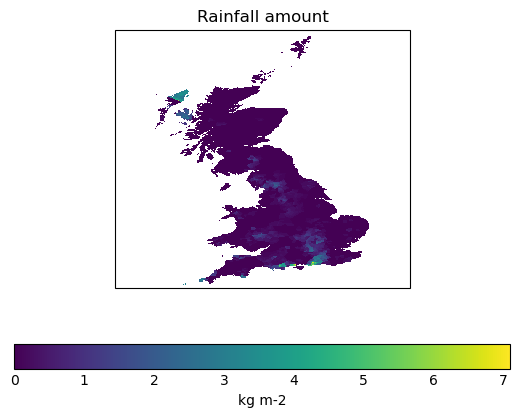

In [172]:
qplt.pcolormesh(regridded_cube[0])

In [2]:
outdir2 = '/data/users/gregory.munday/somerset-compass/01_Data/bucket/forcing/reprojected_GEAR_2/'
for f in tqdm(sorted(glob.glob(outdir + '*.nc'))):
    precip = xr.open_dataset(f)
    precip['rainfall_amount'] = precip.rainfall_amount.assign_attrs(valid_min=0.0, valid_max=500.0)
    precip['rainfall_amount'].values[precip.rainfall_amount.values > 500] = np.nan
    filename = f.split('/')[-1]
    precip.to_netcdf(outdir2 + filename)

100%|██████████| 21/21 [06:35<00:00, 18.84s/it]
